This code runs through the first 4 steps of the GIBF algorithm as laid out in the mathematical roadmap.

1) Genereate CSDM - note that I have 2 cells dedicated to this. One uses a scipy function and calculates the CSDM correctly but it is slow. The other one is an attempt at a manual implementation that would be significantly faster, but I haven`t gotten it to work yet.
2) Select the number of eigenmodes based on the eigenvalue distribution - because of the method I used to bin up the frequncies during the fourier transform part of step 1, there are only 13 nonzero eigenvalues for each bin. I created a skree plot to visualize them for each bin. The bottom line is that it is impossible to visually determine when the eigenvalues are statistically significant 513 times so we need to find a method to automate this. for now I just kept all 13 x 513.
3) Construct the transfer matrix A - I totally vibe coded this, and it returns the correct shape array, but I am dubious that the output is correct. The geometry of the sensors, the resolution of the map and the field physics are all contained in this object so it is possibly the most important part.
4) Ridge regression to create Q_blurry - retaining all of the 13 x 513 eigenmodes makes this step extremely slow right now, but it does appear to be working. Q_blurry will be returned as a stacked vector and will need to have the proper data extracted from it. My current source map creation method may or may not extract the data correctly I have not made sure yet. Alpha must also be tuned. This is a topic in my deep learning class so I will probably be able to make this part more sophisticated soon.

The next steps are as follows: \
5) Iteratively reweighted least squares - should be easy just a regression algorithm. This is also a topic in my deep learning class. \
6) Reduce dimensionality of A as we iterate. - just an extra step in the IRLS process. \
7) Repeate until covergence or a set iteration count - We will eventually use a loss function to check convergence. \
8) Create final source map - we will be creating a blurry source map at step 4 for a sanity check and this will be exactly the same.

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal

# This cell loads the data into an array like this:  sensor_i = [x_i, y_i, z_i], mag_data = [sensor_1, ..., sensor_m ]
# 27 Sensors x 3 time series gives 87 columns. Each time series has 7201 points so there are 7201 rows

np.set_printoptions(precision=2, suppress=True) # no more ugly decimals

folder_path = "/Users/stridersettgast/Downloads/Mag Data" # Copy your path to the data here
folder = Path(folder_path)
text_files = sorted(folder.glob("*.txt"))

all_columns = []

for file_path in text_files:
    # Load the three time series columns
    data = np.loadtxt(file_path, usecols=(7, 8, 9))
    
    # Add each column individually
    all_columns.append(data[:, 0])
    all_columns.append(data[:, 1])
    all_columns.append(data[:, 2])

# Stack all columns
mag_data = np.column_stack(all_columns)

print(f"✓ Loaded {mag_data.shape[0]} rows × {mag_data.shape[1]} columns")
print(f"\nFirst 5 rows (preview):")
print(mag_data[:5, :5])

✓ Loaded 7201 rows × 87 columns

First 5 rows (preview):
[[-13.26  43.12 -20.89  22.75 -72.66]
 [-13.27  43.11 -20.86  22.73 -72.65]
 [-13.3   43.11 -20.9   22.74 -72.63]
 [-13.3   43.07 -20.89  22.73 -72.62]
 [-13.32  43.09 -20.85  22.74 -72.64]]


In [131]:
# Compute CSDM manually by taking the STFT and the outer product using eigensum for efficiency
# This method would be preferable to scipy`s signal.csd() but we need to make sure it is calculating it properly (it is not)

# --- Configuration ---
fs = 1.0        # Sampling frequency
nperseg = 1024  # Segment length
noverlap = nperseg//2  # 50% overlap

# --- Step 1: Compute STFT for all 87 channels at once ---
# mag_data shape: (7201, 87)
# axis=0 computes the STFT along the time dimension for each sensor
frequencies, times, stft_data = signal.stft(
    mag_data, 
    fs=fs, 
    window='hann', 
    nperseg=nperseg, 
    noverlap=noverlap, 
    axis=0,
    detrend='constant',  # Add detrending to match csd()
    boundary=None
)

# Calculate window correction factor
window = signal.get_window('hann', nperseg)
window_correction = np.sum(window**2)  # For power spectra

# Output data shape: (513, 87, 14) 
# (513 frequency bins, 87 sensors, 14 time segments)
print("stft_data shape:", stft_data.shape)                     
print("Number of frequency bins:", frequencies.shape) 
print("Number of time segments:", times.shape) 

# --- Step 2: Compute CSDM using Einstein Summation ---
# 'f_t' represents (frequencies, sensors, time_segments)
# We multiply the sensor vectors and average over the time segments (t)
csdm_manual = np.einsum('fit,fjt->fij', stft_data, np.conj(stft_data), optimize=True)
csdm_manual = csdm_manual / (fs * times.shape[0] * window_correction) 

# --- Final Shape Check ---
print("CSDM shape:", csdm_manual.shape)

stft_data shape: (513, 87, 14)
Number of frequency bins: (513,)
Number of time segments: (14,)
CSDM shape: (513, 87, 87)


In [132]:
# Compute CSDM using scipy`s signal.csd()
# This method is slow but very simple to use

# --- Configuration ---
fs = 1.0  # Sampling frequency
nperseg = 1024  # Segment length
noverlap = nperseg // 2  # 50% overlap is standard

# Reshape arrays to allow NumPy broadcasting to compute all sensor pairs:
# x_input shape becomes: (7201, 87, 1)
# y_input shape becomes: (7201, 1, 87)
x_input = mag_data[:, :, np.newaxis]
y_input = mag_data[:, np.newaxis, :]

# Compute CSDM along the time axis (axis 0)
# SciPy automatically demeans, applies a Hann window, splits into segments, 
# takes the STFT, performs outer products, and takes the expectation (mean)
frequencies, csdm_csd = signal.csd(
    x_input, 
    y_input, 
    fs=fs, 
    window='hann', 
    nperseg=nperseg, 
    noverlap=noverlap, 
    axis=0
)

# --- Final Shape Check ---
print("Number of frequncy bins:", frequencies.shape)  # Output: (513,)
print("CSDM shape:", csdm_csd.shape) # Output: (513, 87, 87)

Number of frequncy bins: (513,)
CSDM shape: (513, 87, 87)


In [133]:
# Compute the eigenvalues and eigenvectors vectorized across all bins

# eigh returns eigenvalues in ascending order
eigenvalues, eigenvectors = np.linalg.eigh(csdm_csd)

# --- Shape Verification ---
print("Eigenvalues shape:", eigenvalues.shape)      # Output: (513, 87)
print("Eigenvectors shape:", eigenvectors.shape)  # Output: (513, 87, 87)

# Compute the element-wise square root of the eigenvalues (clip because they should be positive)
sqrt_eigenvalues = np.sqrt(np.clip(eigenvalues, a_min=0, a_max=None))

# Flip arrays along the last axis to sort eigenvalues from high to low
desc_sqrt_eigenvalues = sqrt_eigenvalues[:, ::-1]
desc_eigenvectors = eigenvectors[:, :, ::-1]

# Multiply each eigenvector column by its corresponding square root eigenvalue
# np.newaxis expands sqrt_eigenvalues from (513, 87) to (513, 1, 87) for proper broadcasting
eigenmodes = desc_eigenvectors * desc_sqrt_eigenvalues[:, np.newaxis, :]

# Retain only the first 13 eigenmodes across all frequency bins 
# Because of the way frequencies were binned up there are only 13 nonzero eigenvalues for each bin
coherent_eigenmodes = eigenmodes[:, :, :13]

# --- Shape Verification ---
print("Coherent Eigenmodes shape:", coherent_eigenmodes.shape)  # Output: (513, 87, 13)

Eigenvalues shape: (513, 87)
Eigenvectors shape: (513, 87, 87)
Coherent Eigenmodes shape: (513, 87, 13)


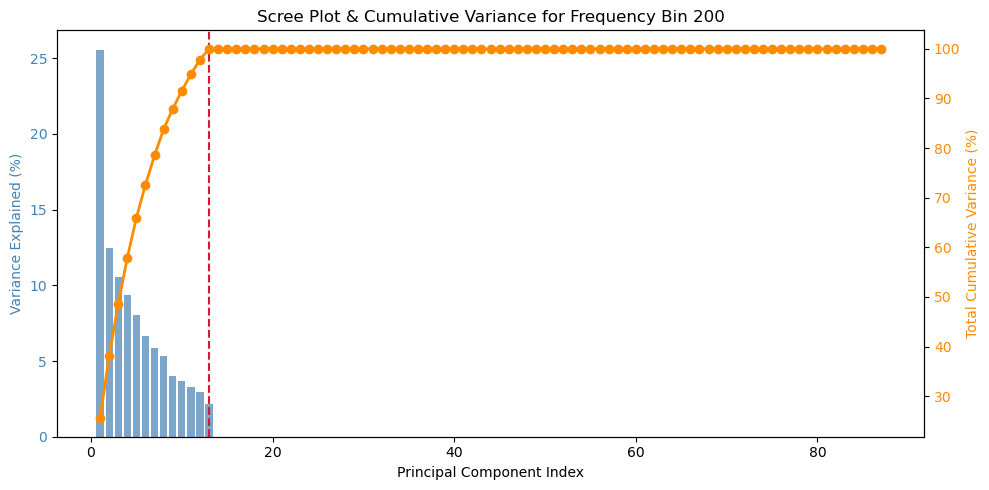

In [134]:
# Scree plot to visualize eigenvalue distribution
# In reality we would like to find a statistical method that can provide a cutoff
# By keeping all 13 nonzero eigenmodes we could be retaining extra noise

# 1. Choose which frequency bin you want to look at (0 to 512)
bin_index = 200

# 2. Extract the sorted eigenvalues for that specific bin
bin_eigenvalues = desc_sqrt_eigenvalues[bin_index]
components = np.arange(1, len(bin_eigenvalues) + 1)

# 3. Calculate the percentage of variance explained by each individual component
variance_explained = (bin_eigenvalues / np.sum(bin_eigenvalues)) * 100
cumulative_variance = np.cumsum(variance_explained)

# 4. Create the dual-axis Scree Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Individual Variance (Bars)
ax1.bar(components, variance_explained, color='steelblue', alpha=0.7, label='Individual Variance')
ax1.set_xlabel('Principal Component Index')
ax1.set_ylabel('Variance Explained (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title(f'Scree Plot & Cumulative Variance for Frequency Bin {bin_index}')

# Plot Cumulative Variance (Line)
ax2 = ax1.twinx()
ax2.plot(components, cumulative_variance, color='darkorange', marker='o', linewidth=2, label='Cumulative Variance')
ax2.set_ylabel('Total Cumulative Variance (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Draw a vertical line at the MDL choice (13 components)
ax1.axvline(x=13, color='crimson', linestyle='--', linewidth=1.5, label='MDL Cutoff (13)')

# Layout adjustment
fig.tight_layout()
plt.show()

In [135]:
# Transfer matrix configuration object

from typing import Tuple, List
from dataclasses import dataclass

@dataclass
class GridPoint:
    """Represents a point in 3D space"""
    x: float
    y: float
    z: float

class GreenFunctionBasis:
    """Different types of source basis functions"""
    
    MONOPOLE = 0      # Scalar source
    DIPOLE_X = 1      # Dipole oriented in x-direction
    DIPOLE_Y = 2      # Dipole oriented in y-direction
    DIPOLE_Z = 3      # Dipole oriented in z-direction
    # Add more as needed: quadrupole, etc.
    
    @staticmethod
    def count_types():
        return 4  # Monopole + 3 dipole components

class TransferMatrixBuilder:
    def __init__(self, sensor_positions: np.ndarray):
        """
        Parameters:
        sensor_positions: (87, 3) array of (x, y, z) for each sensor
        """
        self.sensor_positions = sensor_positions  # (87, 3)
        self.n_sensors = 87
        
    def greens_monopole(self, sensor_pos: np.ndarray, source_pos: np.ndarray) -> float:
        """
        Green's function for monopole source.
        For magnetic fields: 1/r potential
        """
        r = np.linalg.norm(sensor_pos - source_pos)
        if r < 1e-10:  # Avoid singularity
            return 0
        return 1.0 / r
    
    def greens_dipole(self, sensor_pos: np.ndarray, source_pos: np.ndarray, 
                      orientation: np.ndarray) -> np.ndarray:
        """
        Green's function for dipole source.
        For magnetic fields: gradient of 1/r in orientation direction
        """
        r_vec = sensor_pos - source_pos
        r = np.linalg.norm(r_vec)
        if r < 1e-10:
            return np.zeros(3)
        
        # Dipole field: (3*(m·r̂)r̂ - m) / r^3 for magnetic dipole
        # Or gradient of monopole for scalar potential
        r_hat = r_vec / r
        m = orientation / np.linalg.norm(orientation)
        
        # Dipole field at sensor
        field = (3 * np.dot(m, r_hat) * r_hat - m) / (r**3)
        return field
    
    def compute_transfer_matrix(self, grid_points: List[GridPoint], 
                               basis_types: List[int]) -> np.ndarray:
        """
        Build the full transfer matrix.
        
        Parameters:
        grid_points: K grid points in 3D space
        basis_types: List of N basis function types to use
        
        Returns:
        A: Transfer matrix with shape (87, N*K)
        """
        n_sensors = 87
        K = len(grid_points)
        N = len(basis_types)
        n_cols = K * N
        
        # Initialize transfer matrix
        A = np.zeros((n_sensors, n_cols))
        
        for k, source_pos in enumerate(grid_points):
            source_array = np.array([source_pos.x, source_pos.y, source_pos.z])
            
            for b, basis_type in enumerate(basis_types):
                col_idx = k * N + b
                
                for i, sensor_pos in enumerate(self.sensor_positions):
                    if basis_type == GreenFunctionBasis.MONOPOLE:
                        A[i, col_idx] = self.greens_monopole(sensor_pos, source_array)
                        
                    elif basis_type in [GreenFunctionBasis.DIPOLE_X, 
                                       GreenFunctionBasis.DIPOLE_Y,
                                       GreenFunctionBasis.DIPOLE_Z]:
                        # Orientation vector for dipole
                        orientation = np.zeros(3)
                        if basis_type == GreenFunctionBasis.DIPOLE_X:
                            orientation[0] = 1.0
                        elif basis_type == GreenFunctionBasis.DIPOLE_Y:
                            orientation[1] = 1.0
                        elif basis_type == GreenFunctionBasis.DIPOLE_Z:
                            orientation[2] = 1.0
                            
                        field = self.greens_dipole(sensor_pos, source_array, orientation)
                        # For scalar magnetometers, you might want a specific component
                        # Or use vector field components
                        A[i, col_idx] = field[2]  # Example: vertical component (z)
                        # Or store all three components separately
                        
        return A

In [136]:
# Transfer Matrix Configuration

# Step 1: initialize sensor positions (87 sensors)
# In reality, we would load the actual magnetometer positions
np.random.seed(42)  # For reproducibility

# Example: Randomly distributed in spherical coordinates
# This creates sensors at given latitudes and longitudes

EARTH_RADIUS = 6371000.0

# Choose latitudes and longitudes
latitudes = np.linspace(-80, 80, 10)  # 10 latitudes (skip poles)
longitudes = np.linspace(0, 360, 9, endpoint=False)  # 9 longitudes
# 10 × 9 = 90 points, we'll take first 87

sensor_positions = []

for lat in latitudes:
    for lon in longitudes[:9]:  # Take first 9 longitudes
        # Convert to radians
        lat_rad = np.radians(lat)
        lon_rad = np.radians(lon)
        
        # Spherical to Cartesian
        x = EARTH_RADIUS * np.cos(lat_rad) * np.cos(lon_rad)
        y = EARTH_RADIUS * np.cos(lat_rad) * np.sin(lon_rad)
        z = EARTH_RADIUS * np.sin(lat_rad)
        
        sensor_positions.append([x, y, z])
        
        if len(sensor_positions) >= 87:
            break
    if len(sensor_positions) >= 87:
        break

sensor_positions = np.array(sensor_positions)

# Step 2: Define your grid points (source locations)
# These are potential source locations you want to image
grid_x = np.linspace(-6, 6, 10)   # 10 points in x
grid_y = np.linspace(-6, 6, 10)   # 10 points in y
grid_z = np.linspace(-3, 3, 5)    # 5 points in z

grid_points = []
for x in grid_x:
    for y in grid_y:
        for z in grid_z:
            grid_points.append(GridPoint(x, y, z))

K = len(grid_points)  # Number of grid points

# Step 3: Define which basis functions to use
basis_types = [
    GreenFunctionBasis.MONOPOLE,
    GreenFunctionBasis.DIPOLE_X,
    GreenFunctionBasis.DIPOLE_Y,
    GreenFunctionBasis.DIPOLE_Z
]
N = len(basis_types)  # N = 4 basis functions per grid point

# Step 4: Build the transfer matrix A
builder = TransferMatrixBuilder(sensor_positions)
A = builder.compute_transfer_matrix(grid_points, basis_types)

print(f"A is of shape: {A.shape}")

A is of shape: (87, 2000)


In [137]:
# Ridge regression on each eigenmode

alpha = 0.1 # This parameter can be tuned

# --- Setup Dimensions ---
n_freqs, n_channels, n_modes = coherent_eigenmodes.shape  # (513, 87, 13)

# Define your feature matrix 'A' and regularization parameter 'alpha'
# 'A' must have 87 rows to match the 87 channels in your eigenmodes
# Shape of A: (87, n_features)
n_features = A.shape[1] 

# Initialize an empty array to store the regression weights (x)
# Shape: (513, n_features, 13)
Q_blurry = np.zeros((n_freqs, n_features, n_modes), dtype=complex)

# --- Optimized Execution Loop ---
# Pre-compute normal equation matrices that depend only on 'A' and 'alpha'
ATA = A.T @ A
reg_matrix = ATA + alpha * np.eye(n_features)
L = np.linalg.cholesky(reg_matrix)
LT = L.T

# Loop over each frequency bin
for f in range(n_freqs):
    # Extract all 13 eigenmodes for this specific frequency bin
    # Shape: (87, 13) -> Process all 13 modes at once as a batch matrix 'b'
    b_batch = coherent_eigenmodes[f, :, :]
    
    # Solve L y = A^T b for all 13 columns simultaneously
    ATb = A.T @ b_batch
    y = np.linalg.solve(L, ATb)

    # Solve L^T x = y to get the final regression coefficients
    x_batch = np.linalg.solve(LT, y)
    
    # Store the result for this frequency bin
    Q_blurry[f, :, :] = x_batch

# --- Shape Verification ---
print("Q_blurry shape:", Q_blurry.shape)  # Output: (513, 2000, 13)

Q_blurry shape: (513, 2000, 13)


In [138]:
# Create the blurry source map

# New shape: (513, K, N, 13)
Q_blurry_reshaped = Q_blurry.reshape(513, K, N, 13)

# Sum magnitudes squared across the source types and eigenmodes to isolate the spatial power grid
source_power_blurry = np.sum(np.abs(Q_blurry_reshaped)**2, axis=(2, 3))

# --- Shape Verification ---
print("Q_blurry_reshaped shape:", Q_blurry_reshaped.shape)      # Output: (513, K, N, 13)
print("Source Power Map shape:", source_power_blurry.shape)  # Output: (513, K)

Q_blurry_reshaped shape: (513, 500, 4, 13)
Source Power Map shape: (513, 500)
